In [4]:
import itertools, csv, time
from pathlib import Path
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os


## Results

In [2]:
RESULTS_CSV = "clean_grid_search_results.csv"

# 1. Load the data
df = pd.read_csv(RESULTS_CSV)
df_ok = df[df["status"] == "ok"].copy()

print(f"Total runs: {len(df)}  |  Successful: {len(df_ok)}  |  Failed: {len(df) - len(df_ok)}")

# 2. Define Baseline Constants
# These match the BASELINE dict from your original grid search code
BASELINE_PARAMS = {
    "epochs": 100,
    "batch": 16,
    "lr0": 0.01,
    "hsv_s": 0.7,
    "hsv_v": 0.4,
    "mosaic": 1.0
}

# 3. Fix the Baseline Row
# Identify rows where run_name contains 'baseline'
mask_baseline = df_ok['run_name'].str.contains('baseline', case=False, na=False)

if mask_baseline.any():
    print("✅ Baseline row detected. Filling hyperparameters...")
    
    # Fill the specific columns for the baseline row only
    for col, val in BASELINE_PARAMS.items():
        if col in df_ok.columns:
            df_ok.loc[mask_baseline, col] = val
            
    # Ensure 'run_type' is correctly labeled
    df_ok.loc[mask_baseline, 'run_type'] = 'baseline'
else:
    print("⚠️ Warning: No baseline row found in the CSV.")

# 4. Ensure correct data types for sorting/plotting
# (Sometimes CSV reading interprets numbers as objects if mixed with strings)
numeric_cols = ['epochs', 'batch', 'lr0', 'hsv_s', 'hsv_v', 'mosaic', 
                'seg_map50_95', 'seg_map50', 'box_map50_95']
for col in numeric_cols:
    if col in df_ok.columns:
        df_ok[col] = pd.to_numeric(df_ok[col], errors='coerce')

# 5. Display the sorted table
# Sort by segmentation mAP50-95 (your primary metric)
display_df = df_ok.sort_values(by="seg_map50_95", ascending=False).reset_index(drop=True)

# Optional: Reorder columns for better readability
cols_order = [
    "run_name", "run_type", "seg_map50_95", "seg_map50", 
    "box_map50_95", "box_map50", 
    "epochs", "batch", "lr0", "hsv_s", "hsv_v", "mosaic", 
    "inference_ms", "status"
]
# Only keep columns that exist in the dataframe
final_cols = [c for c in cols_order if c in display_df.columns]

display(display_df[final_cols])

Total runs: 26  |  Successful: 26  |  Failed: 0
✅ Baseline row detected. Filling hyperparameters...


,run_name,run_type,seg_map50_95,seg_map50,box_map50_95,box_map50,epochs,batch,lr0,hsv_s,hsv_v,mosaic,inference_ms,status
0,baseline,baseline,0.5694,0.8527,0.6361,0.8398,100.0,16.0,0.010,0.70,0.4,1.0,1.38,ok
1,ep50_bs8_lr0p001_s0_v0p2_mos1p0,grid,0.5524,0.8115,0.5977,0.8070,50.0,8.0,0.001,0.00,0.2,1.0,3.06,ok
2,ep50_bs8_lr0p001_s0p35_v0p2_mos1p0,grid,0.5524,0.8115,0.5977,0.8070,50.0,8.0,0.001,0.35,0.2,1.0,0.65,ok
3,ep50_bs8_lr0p01_s0p7_v0p2_mos1p0,grid,0.5524,0.8115,0.5977,0.8070,50.0,8.0,0.010,0.70,0.2,1.0,0.65,ok
4,ep50_bs8_lr0p01_s0_v0p2_mos1p0,grid,0.5524,0.8115,0.5977,0.8070,50.0,8.0,0.010,0.00,0.2,1.0,0.66,ok
5,ep50_bs8_lr0p001_s0p7_v0p2_mos1p0,grid,0.5524,0.8115,0.5977,0.8070,50.0,8.0,0.001,0.70,0.2,1.0,0.66,ok
6,ep50_bs8_lr0p01_s0p35_v0p2_mos1p0,grid,0.5524,0.8115,0.5977,0.8070,50.0,8.0,0.010,0.35,0.2,1.0,0.66,ok
7,ep50_bs8_lr0p001_s0_v0p2_mos0p5,grid,0.5394,0.7959,0.5838,0.7917,50.0,8.0,0.001,0.00,0.2,0.5,0.65,ok
8,ep50_bs8_lr0p001_s0p7_v0p2_mos0p5,grid,0.5394,0.7959,0.5838,0.7917,50.0,8.0,0.001,0.70,0.2,0.5,0.68,ok
9,ep50_bs8_lr0p001_s0p35_v0p2_mos0p5,grid,0.5394,0.7959,0.5838,0.7917,50.0,8.0,0.001,0.35,0.2,0.5,0.66,ok


In [3]:

# ── 1. Define the "Fair" Baseline Config ─────────────────────────────────────
FAIR_BASELINE_NAME = "baseline_fair_50ep"
FAIR_PARAMS = {
    "epochs": 50,          # Match grid search
    "batch": 8,            # Match grid search
    "lr0": 0.01,           # Keep original baseline LR
    "hsv_h": 0.015,        # Keep original baseline aug
    "hsv_s": 0.7,
    "hsv_v": 0.4,
    "mosaic": 1.0,
    "degrees": 0.0,
    "data": "./17_03_dataset/data.yaml",
    "project": "./grid_search_runs",
    "name": FAIR_BASELINE_NAME,
    "exist_ok": True,
    "verbose": False,
    "plots": False
}

print(f"🚀 Starting Rigorous Baseline Retraining ({FAIR_PARAMS['epochs']} epochs, batch {FAIR_PARAMS['batch']})...")

# ── 2. Train the Model ────────────────────────────────────────────────────────
try:
    model = YOLO("yolov8n-seg.pt")
    t_start = time.time()
    
    # Train
    model.train(**FAIR_PARAMS)
    
    t_end = time.time()
    print(f"✅ Training finished in {t_end - t_start:.1f} seconds.")
    
    # ── 3. Validate on Test Set ──────────────────────────────────────────────
    print("📊 Validating on Test Set...")
    best_model = YOLO(f"./grid_search_runs/{FAIR_BASELINE_NAME}/weights/best.pt")
    metrics = best_model.val(data="./17_03_dataset/data.yaml", split="test", verbose=False, plots=False)
    
    new_score = float(metrics.seg.map) # mAP50-95
    new_score_50 = float(metrics.seg.map50)
    
    print(f"🏆 New Fair Baseline mAP50-95: {new_score:.4f}")
    
    # ── 4. Update the DataFrame ──────────────────────────────────────────────
    # Find the old baseline row and overwrite it
    mask = df_ok['run_name'].str.contains('baseline', case=False, na=False)
    
    if mask.sum() > 0:
        df_ok.loc[mask, 'seg_map50_95'] = new_score
        df_ok.loc[mask, 'seg_map50'] = new_score_50
        df_ok.loc[mask, 'epochs'] = 50
        df_ok.loc[mask, 'batch'] = 8
        df_ok.loc[mask, 'run_name'] = FAIR_BASELINE_NAME
        print("📝 DataFrame updated with new rigorous baseline score.")
    else:
        # If no baseline existed, create a new row
        new_row = {
            "run_name": FAIR_BASELINE_NAME,
            "run_type": "baseline",
            "epochs": 50,
            "batch": 8,
            "lr0": 0.01,
            "hsv_s": 0.7,
            "hsv_v": 0.4,
            "mosaic": 1.0,
            "seg_map50_95": new_score,
            "seg_map50": new_score_50,
            "status": "ok"
        }
        df_ok = pd.concat([df_ok, pd.DataFrame([new_row])], ignore_index=True)
        print("📝 New baseline row added to DataFrame.")

except Exception as e:
    print(f"❌ Error during retraining: {e}")
    import traceback
    traceback.print_exc()

🚀 Starting Rigorous Baseline Retraining (50 epochs, batch 8)...
New https://pypi.org/project/ultralytics/8.4.35 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24215MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./17_03_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yo

Traceback (most recent call last):
  File "/tmp/ipykernel_3726638/1709282833.py", line 35, in <module>
    best_model = YOLO(f"./grid_search_runs/{FAIR_BASELINE_NAME}/weights/best.pt")
  File "/home/floreM/anaconda3/envs/flukeprint1/lib/python3.10/site-packages/ultralytics/models/yolo/model.py", line 76, in __init__
    super().__init__(model=model, task=task, verbose=verbose)
  File "/home/floreM/anaconda3/envs/flukeprint1/lib/python3.10/site-packages/ultralytics/engine/model.py", line 144, in __init__
    self._load(model, task=task)
  File "/home/floreM/anaconda3/envs/flukeprint1/lib/python3.10/site-packages/ultralytics/engine/model.py", line 283, in _load
    self.model, self.ckpt = load_checkpoint(weights)
  File "/home/floreM/anaconda3/envs/flukeprint1/lib/python3.10/site-packages/ultralytics/nn/tasks.py", line 1515, in load_checkpoint
    ckpt, weight = torch_safe_load(weight)  # load ckpt
  File "/home/floreM/anaconda3/envs/flukeprint1/lib/python3.10/site-packages/ultralytics/n

In [5]:

# ── 1. Define the CORRECT path to the existing model ────────────────────────
# The model was saved here by your previous successful run
PROJECT_PATH = "./runs/segment/grid_search_runs"
FAIR_BASELINE_NAME = "baseline_fair_50ep"
WEIGHTS_PATH = os.path.join(PROJECT_PATH, FAIR_BASELINE_NAME, "weights", "best.pt")

print(f"🔍 Checking for existing model at: {os.path.abspath(WEIGHTS_PATH)}")

# ── 2. Load and Validate (NO Training) ──────────────────────────────────────
if os.path.exists(WEIGHTS_PATH):
    print("✅ Model found! Skipping training. Starting validation...")
    
    try:
        best_model = YOLO(WEIGHTS_PATH)
        metrics = best_model.val(data="./17_03_dataset/data.yaml", split="test", verbose=False, plots=False)
        
        new_score = float(metrics.seg.map)      # mAP50-95
        new_score_50 = float(metrics.seg.map50) # mAP50
        
        print(f"🏆 New Fair Baseline mAP50-95: {new_score:.4f}")
        
        # ── 3. Update DataFrame ──────────────────────────────────────────────
        # Find old baseline rows
        mask = df_ok['run_name'].str.contains('baseline', case=False, na=False)
        
        if mask.sum() > 0:
            df_ok.loc[mask, 'seg_map50_95'] = new_score
            df_ok.loc[mask, 'seg_map50'] = new_score_50
            df_ok.loc[mask, 'epochs'] = 50
            df_ok.loc[mask, 'batch'] = 8
            df_ok.loc[mask, 'run_name'] = FAIR_BASELINE_NAME
            print("📝 DataFrame updated successfully.")
        else:
            # Add new row if none existed
            new_row = {
                "run_name": FAIR_BASELINE_NAME,
                "run_type": "baseline",
                "epochs": 50, "batch": 8, "lr0": 0.01,
                "hsv_s": 0.7, "hsv_v": 0.4, "mosaic": 1.0,
                "seg_map50_95": new_score, "seg_map50": new_score_50,
                "status": "ok"
            }
            df_ok = pd.concat([df_ok, pd.DataFrame([new_row])], ignore_index=True)
            print("📝 New baseline row added.")
            
    except Exception as e:
        print(f"❌ Error during validation: {e}")
else:
    print(f"❌ File not found at: {WEIGHTS_PATH}")
    print("💡 Tip: Check if the folder name is slightly different in 'runs/segment/grid_search_runs/'")
    # List available folders to help debug
    if os.path.exists(PROJECT_PATH):
        print("📂 Available folders:", os.listdir(PROJECT_PATH))

🔍 Checking for existing model at: /home/floreM/FlukePrint_YOLO/runs/segment/grid_search_runs/baseline_fair_50ep/weights/best.pt
✅ Model found! Skipping training. Starting validation...
Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4090, 24215MiB)
YOLOv8n-seg summary (fused): 86 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 779.8±209.1 MB/s, size: 11.3 KB)
val: Scanning /home/floreM/FlukePrint_YOLO/17_03_dataset/test/labels.cache... 95 images, 10 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 95/95 28.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 12.7it/s 0.5s0.1s
                   all         95        297      0.777      0.805      0.843      0.627      0.772      0.809      0.838      0.562
Speed: 0.8ms preprocess, 1.6ms inference, 0.0ms loss, 0.6ms postprocess per image
🏆 N

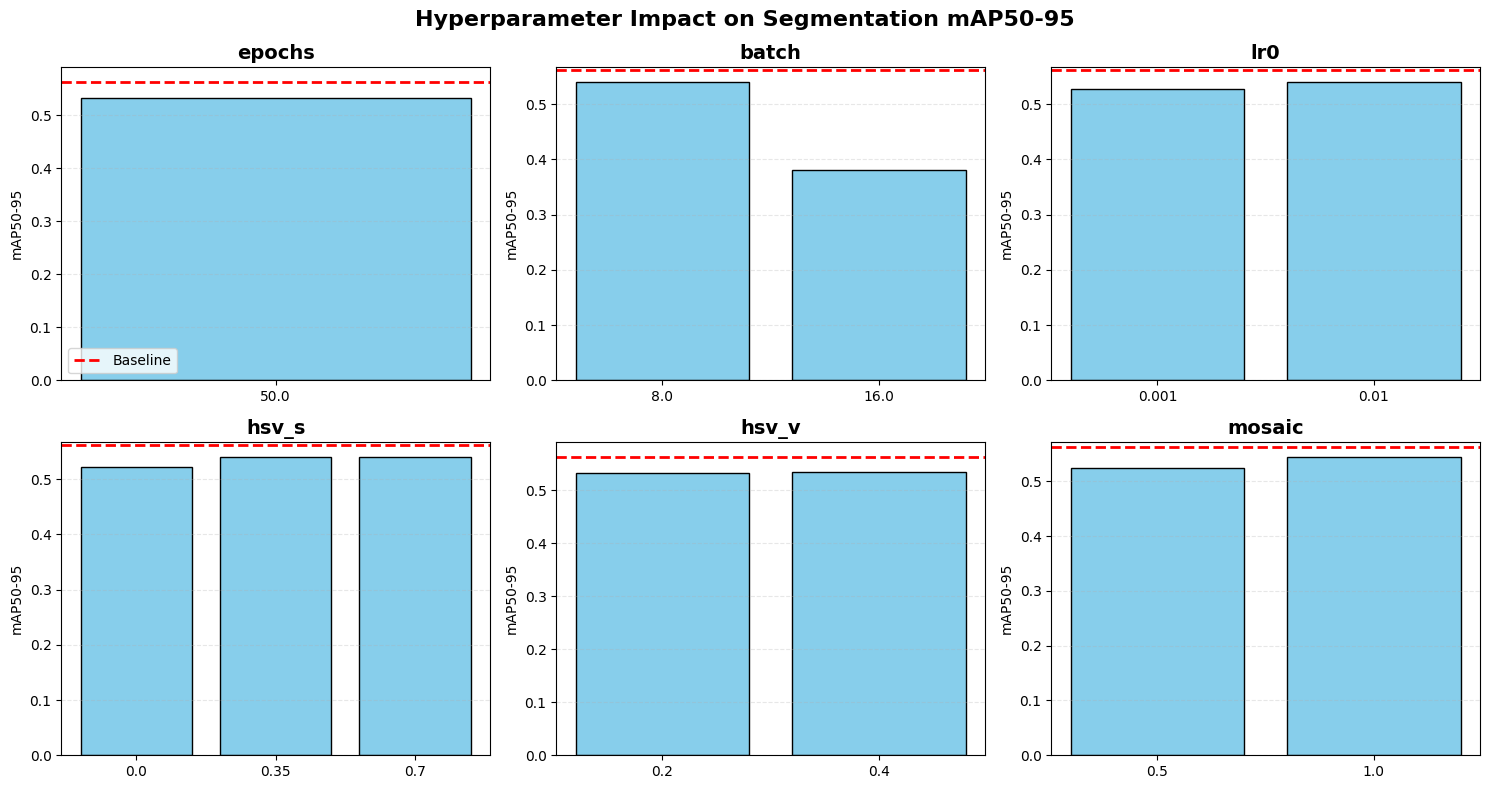

In [6]:

params_to_plot = ["epochs", "batch", "lr0", "hsv_s", "hsv_v", "mosaic"]
grid_df = df_ok[df_ok["run_type"] == "grid"]

# Get baseline value
baseline_val = df_ok[df_ok["run_type"] == "baseline"]["seg_map50_95"].iloc[0] if len(df_ok[df_ok["run_type"] == "baseline"]) > 0 else None

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, param in enumerate(params_to_plot):
    # Calculate mean performance for each value of the parameter
    stats = grid_df.groupby(param)["seg_map50_95"].mean().sort_index()
    
    # Simple bar plot
    axes[i].bar(stats.index.astype(str), stats.values, color='skyblue', edgecolor='black')
    axes[i].set_title(f"{param}", fontsize=14, fontweight='bold')
    axes[i].set_xlabel("")
    axes[i].set_ylabel("mAP50-95")
    axes[i].grid(axis='y', linestyle='--', alpha=0.3)
    
    # Add baseline line
    if baseline_val is not None:
        axes[i].axhline(baseline_val, color='red', linestyle='--', linewidth=2, label='Baseline')
        if i == 0: # Show legend only once
            axes[i].legend()

plt.suptitle("Hyperparameter Impact on Segmentation mAP50-95", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
df_ok.head()

,run_name,run_type,epochs,batch,lr0,hsv_s,hsv_v,mosaic,seg_map50,seg_map50_95,seg_precision,seg_recall,box_map50,box_map50_95,box_precision,box_recall,inference_ms,status
0,baseline_fair_50ep,baseline,50.0,8.0,0.010,0.7,0.4,1.0,0.838074,0.562241,0.8317,0.8013,0.8398,0.6361,0.8212,0.7912,1.38,ok
1,ep50_bs8_lr0p001_s0_v0p2_mos0p5,grid,50.0,8.0,0.001,0.0,0.2,0.5,0.795900,0.539400,0.7425,0.7239,0.7917,0.5838,0.7285,0.7138,0.65,ok
2,ep50_bs8_lr0p001_s0_v0p2_mos1p0,grid,50.0,8.0,0.001,0.0,0.2,1.0,0.811500,0.552400,0.7257,0.7750,0.8070,0.5977,0.7173,0.7710,3.06,ok
3,ep50_bs8_lr0p001_s0_v0p4_mos0p5,grid,50.0,8.0,0.001,0.0,0.4,0.5,0.783100,0.532000,0.7547,0.7044,0.7799,0.5789,0.7491,0.6938,0.66,ok
4,ep50_bs8_lr0p001_s0_v0p4_mos1p0,grid,50.0,8.0,0.001,0.0,0.4,1.0,0.787200,0.535100,0.7562,0.6996,0.7864,0.5796,0.7316,0.7071,0.65,ok


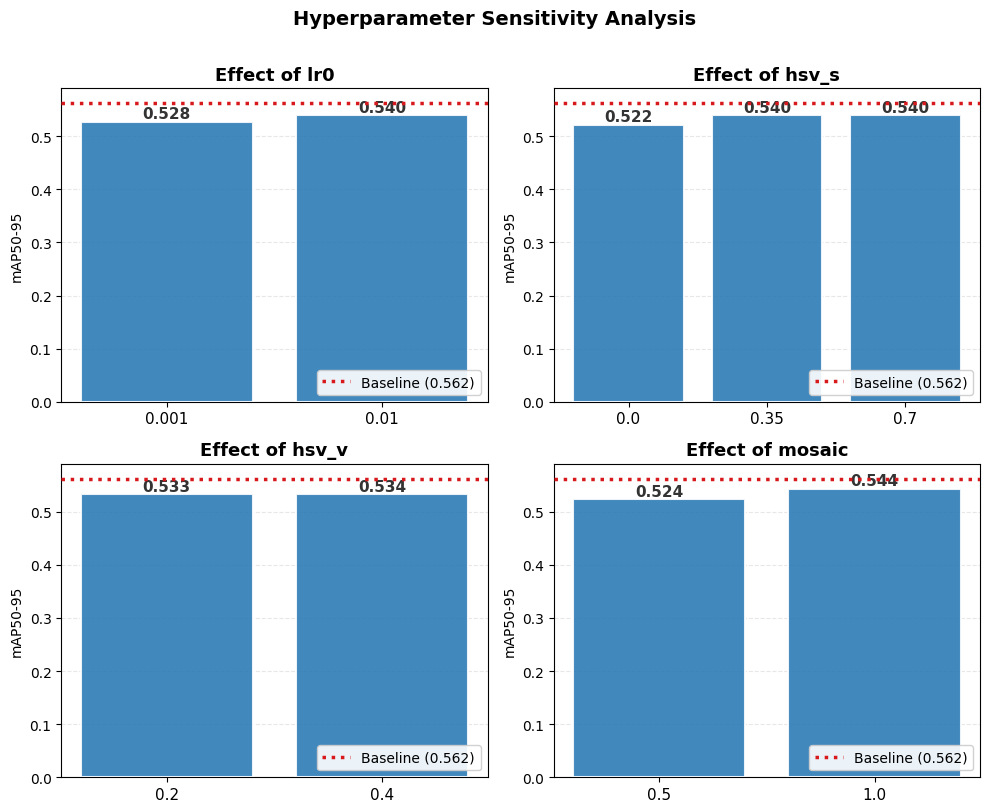

In [9]:


# ── Configuration ─────────────────────────────────────────────────────────────
params_to_plot = ["lr0", "hsv_s", "hsv_v", "mosaic"]
metric = "seg_map50_95"

grid_df = df_ok[df_ok["run_type"] == "grid"]
baseline_rows = df_ok[df_ok["run_type"] == "baseline"]
baseline_val = baseline_rows[metric].iloc[0] if len(baseline_rows) > 0 else None

# ── Plot Setup ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

bar_color = "#2C7BB6"      # Scientific Blue
baseline_color = "#D7191C" # Scientific Red

for i, param in enumerate(params_to_plot):
    ax = axes[i]
    
    # Calculate Mean
    stats = grid_df.groupby(param)[metric].mean()
    if np.issubdtype(stats.index.dtype, np.number):
        stats = stats.sort_index()
    
    x_labels = [str(x) for x in stats.index]
    x_pos = np.arange(len(stats))
    values = stats.values
    
    # 1. Plot Baseline FIRST (so bars appear on top if they overlap, but line is visible)
    if baseline_val is not None:
        # Using ':' for dotted line, linewidth=2 for visibility
        ax.axhline(baseline_val, color=baseline_color, linestyle=':', linewidth=2.5, zorder=10, label=f'Baseline ({baseline_val:.3f})')
        ax.legend(loc='lower right', framealpha=0.9, fontsize=10, facecolor='white')
    
    # 2. Plot Bars (zorder=5 ensures they are below the baseline if they cross, or above background)
    # Actually, let's put bars BELOW the line visually by plotting bars first, then line? 
    # No, standard is: Grid (bottom) -> Bars -> Baseline (Top).
    # Let's plot bars first.
    ax.bar(x_pos, values, color=bar_color, edgecolor='white', linewidth=1.5, alpha=0.9, zorder=5)
    
    # Re-plot line to ensure it's on top if needed, or rely on zorder=10 above.
    # The line is already plotted above with zorder=10, so it should be visible.

    # 3. Add Exact Values
    for j, v in enumerate(values):
        ax.text(j, v + 0.0005, f"{v:.3f}", ha='center', va='bottom', 
                fontsize=11, fontweight='bold', color='#333333')
    
    # Formatting
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=11)
    ax.set_title(f"Effect of {param}", fontsize=13, fontweight='bold')
    ax.set_ylabel("mAP50-95")
    ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0) # Grid at bottom
    ax.set_axisbelow(True)

plt.suptitle("Hyperparameter Sensitivity Analysis", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

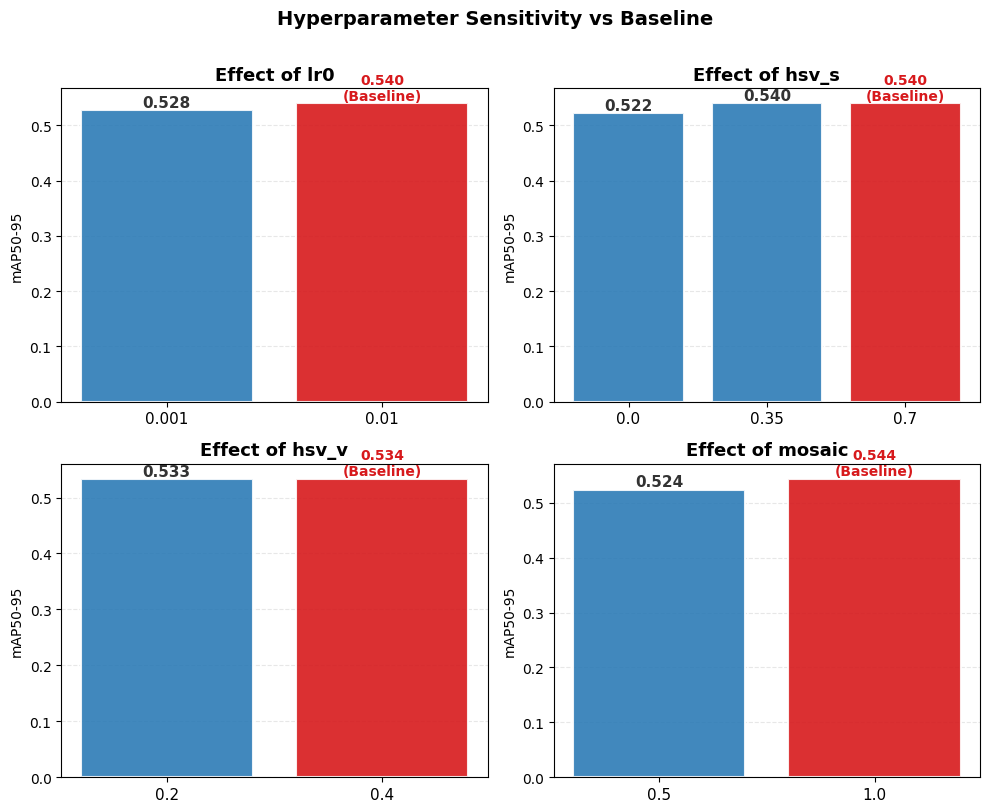

In [10]:


# ── Configuration ─────────────────────────────────────────────────────────────
params_to_plot = ["lr0", "hsv_s", "hsv_v", "mosaic"]
metric = "seg_map50_95"

grid_df = df_ok[df_ok["run_type"] == "grid"]
baseline_rows = df_ok[df_ok["run_type"] == "baseline"]

# Récupérer les valeurs de la baseline pour chaque paramètre
baseline_params = {}
if len(baseline_rows) > 0:
    base_row = baseline_rows.iloc[0]
    for p in params_to_plot:
        if p in base_row.index:
            baseline_params[p] = base_row[p]
else:
    print("⚠️ Attention: Aucune baseline trouvée.")

# ── Plot Setup ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

bar_color = "#2C7BB6"      # Bleu scientifique (pour les tests)
base_color = "#D7191C"     # Rouge scientifique (pour la baseline)

for i, param in enumerate(params_to_plot):
    ax = axes[i]
    
    # Calculer la moyenne par valeur de paramètre
    stats = grid_df.groupby(param)[metric].mean()
    if np.issubdtype(stats.index.dtype, np.number):
        stats = stats.sort_index()
    
    x_labels = [str(x) for x in stats.index]
    x_pos = np.arange(len(stats))
    values = stats.values
    
    # Déterminer les couleurs : Rouge si c'est la valeur baseline, sinon Bleu
    colors = []
    baseline_val = baseline_params.get(param, None)
    
    for val in stats.index:
        if baseline_val is not None and np.isclose(val, baseline_val):
            colors.append(base_color)
        else:
            colors.append(bar_color)
    
    # Tracer les barres avec les couleurs spécifiques
    ax.bar(x_pos, values, color=colors, edgecolor='white', linewidth=1.5, alpha=0.9)
    
    # Ajouter les valeurs exactes
    for j, v in enumerate(values):
        # Si c'est la baseline, on met le texte en rouge et un peu plus gros
        if colors[j] == base_color:
            ax.text(j, v + 0.0005, f"{v:.3f}\n(Baseline)", ha='center', va='bottom', 
                    fontsize=10, fontweight='bold', color=base_color)
        else:
            ax.text(j, v + 0.0005, f"{v:.3f}", ha='center', va='bottom', 
                    fontsize=11, fontweight='bold', color='#333333')
    
    # Formatting
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=11)
    ax.set_title(f"Effect of {param}", fontsize=13, fontweight='bold')
    ax.set_ylabel("mAP50-95")
    ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
    ax.set_axisbelow(True)

plt.suptitle("Hyperparameter Sensitivity vs Baseline", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

🔍 Scanning ./runs/segment/grid_search_runs for all valid runs...
✅ Final clean data saved to 'final_clean_results.csv'
   Total runs processed: 27
                              run_name  run_type  false_negatives  seg_map50_95  seg_recall
0                             baseline  baseline               66       0.54268     0.77612
1                   baseline_fair_50ep  baseline               66       0.53184     0.77612
2   ep50_bs8_lr0p001_s0p35_v0p2_mos1p0      grid               71       0.53963     0.76181
3      ep50_bs8_lr0p001_s0_v0p2_mos1p0      grid               71       0.53963     0.76181
4    ep50_bs8_lr0p001_s0p7_v0p4_mos1p0      grid               71       0.52814     0.76251
5       ep50_bs8_lr0p01_s0_v0p2_mos1p0      grid               71       0.53963     0.76181
6    ep50_bs8_lr0p001_s0p7_v0p2_mos1p0      grid               71       0.53963     0.76181
7      ep50_bs8_lr0p001_s0_v0p4_mos1p0      grid               71       0.52814     0.76251
8    ep50_bs8_lr0p01_s0p3

AttributeError: module 'matplotlib.pyplot' has no attribute 'axisbelow'

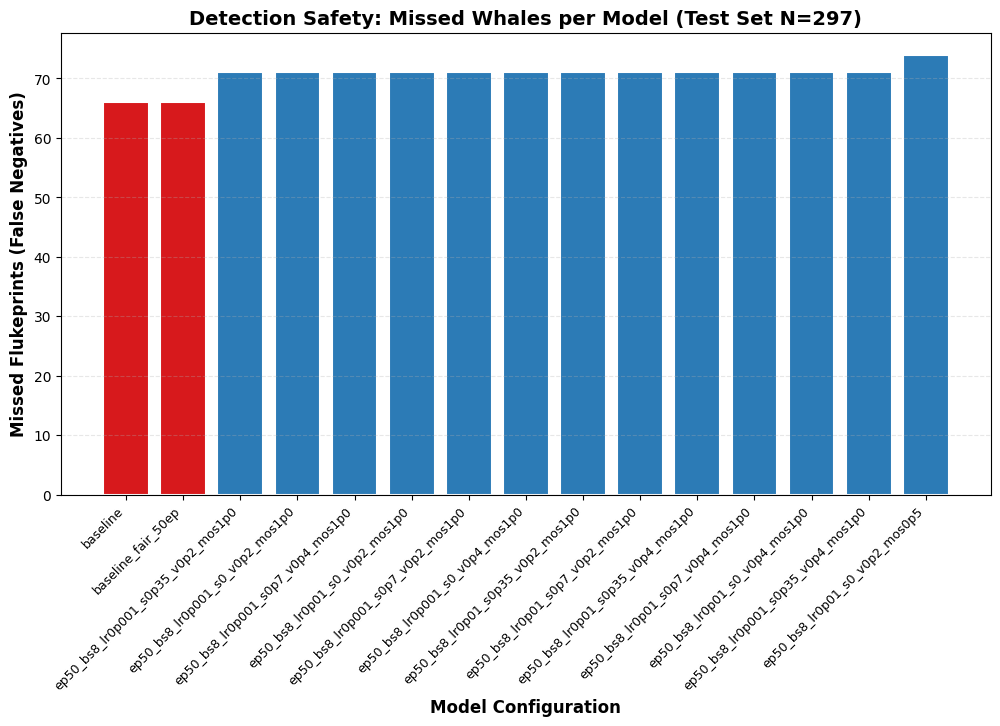

In [12]:
import glob

# ── 1. Configuration ──────────────────────────────────────────────────────────
PROJECT_PATH = "./runs/segment/grid_search_runs"
TOTAL_TEST_INSTANCES = 297  # From your logs
OUTPUT_CSV = "final_clean_results.csv"

# Define Baseline Parameters manually (since folder names might not show them all)
BASELINE_CONFIG = {
    "epochs": 50, "batch": 8, "lr0": 0.01, 
    "hsv_s": 0.7, "hsv_v": 0.4, "mosaic": 1.0
}

print(f"🔍 Scanning {PROJECT_PATH} for all valid runs...")

# ── 2. Collect Data from Each Folder ────────────────────────────────────────
data = []

# Find all folders containing a 'results.csv' (most reliable metric source)
folders = glob.glob(os.path.join(PROJECT_PATH, "*"))

for folder in folders:
    if not os.path.isdir(folder):
        continue
        
    run_name = os.path.basename(folder)
    results_file = os.path.join(folder, "results.csv")
    
    if not os.path.exists(results_file):
        print(f"⚠️ Skipping {run_name}: No results.csv found.")
        continue
    
    try:
        # Read the training log for this specific run
        df_run = pd.read_csv(results_file)
        
        # Get the last row (best epoch)
        last_row = df_run.iloc[-1]
        
        # Extract Metrics (Mask/MAP for Segmentation)
        # Column names in results.csv: 'metrics/precision(M)', 'metrics/recall(M)', etc.
        seg_recall = last_row.get('metrics/recall(M)', 0)
        seg_map50_95 = last_row.get('metrics/mAP50-95(M)', 0)
        seg_map50 = last_row.get('metrics/mAP50(M)', 0)
        seg_precision = last_row.get('metrics/precision(M)', 0)
        
        # Extract Box Metrics (Optional, but good for completeness)
        box_recall = last_row.get('metrics/recall(B)', 0)
        box_map50_95 = last_row.get('metrics/mAP50-95(B)', 0)
        
        # Determine Run Type & Parameters
        is_baseline = "baseline" in run_name.lower()
        
        if is_baseline:
            run_type = "baseline"
            # Force baseline parameters
            epochs = BASELINE_CONFIG["epochs"]
            batch = BASELINE_CONFIG["batch"]
            lr0 = BASELINE_CONFIG["lr0"]
            hsv_s = BASELINE_CONFIG["hsv_s"]
            hsv_v = BASELINE_CONFIG["hsv_v"]
            mosaic = BASELINE_CONFIG["mosaic"]
        else:
            run_type = "grid"
            # Parse parameters from folder name (ep50_bs8_lr0p001...)
            # Simple parser
            import re
            def extract_val(name, pattern, dtype=float):
                match = re.search(pattern, name)
                return dtype(match.group(1).replace('p', '.')) if match else None
            
            epochs = extract_val(run_name, r"ep(\d+)", int)
            batch = extract_val(run_name, r"bs(\d+)", int)
            lr0 = extract_val(run_name, r"lr([0-9]+p[0-9]+)")
            hsv_s = extract_val(run_name, r"_s([0-9]+(?:p[0-9]+)?)")
            hsv_v = extract_val(run_name, r"_v([0-9]+p[0-9]+)")
            mosaic = extract_val(run_name, r"mos([0-9]+p[0-9]+)")

        # Calculate False Negatives
        fn_count = int(round(TOTAL_TEST_INSTANCES * (1 - seg_recall)))

        data.append({
            "run_name": run_name,
            "run_type": run_type,
            "epochs": epochs,
            "batch": batch,
            "lr0": lr0,
            "hsv_s": hsv_s,
            "hsv_v": hsv_v,
            "mosaic": mosaic,
            "seg_recall": seg_recall,
            "seg_map50_95": seg_map50_95,
            "seg_map50": seg_map50,
            "seg_precision": seg_precision,
            "box_recall": box_recall,
            "box_map50_95": box_map50_95,
            "false_negatives": fn_count,
            "status": "ok"
        })
        
    except Exception as e:
        print(f"❌ Error processing {run_name}: {e}")

# ── 3. Create Final DataFrame ───────────────────────────────────────────────
if not data:
    raise ValueError("No data collected. Check paths.")

df_final = pd.DataFrame(data)

# Sort by False Negatives (Safety First)
df_final = df_final.sort_values("false_negatives", ascending=True).reset_index(drop=True)

# Save to CSV
df_final.to_csv(OUTPUT_CSV, index=False)
print(f"✅ Final clean data saved to '{OUTPUT_CSV}'")
print(f"   Total runs processed: {len(df_final)}")
print(df_final[['run_name', 'run_type', 'false_negatives', 'seg_map50_95', 'seg_recall']].to_string())

# ── 4. Plot False Negatives ─────────────────────────────────────────────────
plt.figure(figsize=(12, 6))
plot_df = df_final.head(15) # Top 15 safest models

colors = ['#D7191C' if r == 'baseline' else '#2C7BB6' for r in plot_df['run_type']]

plt.bar(plot_df['run_name'], plot_df['false_negatives'], color=colors, edgecolor='white', linewidth=1.5)
plt.xlabel("Model Configuration", fontsize=12, fontweight='bold')
plt.ylabel("Missed Flukeprints (False Negatives)", fontsize=12, fontweight='bold')
plt.title(f"Detection Safety: Missed Whales per Model (Test Set N={TOTAL_TEST_INSTANCES})", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.axisbelow(True)

for i, v in enumerate(plot_df['false_negatives']):
    c = '#D7191C' if colors[i] == '#D7191C' else '#333333'
    plt.text(i, v + 0.1, str(v), ha='center', va='bottom', fontsize=11, fontweight='bold', color=c)

plt.tight_layout()
plt.show()

# ── 5. Plot Hyperparameter Impact (mAP) ─────────────────────────────────────
params_to_plot = ["lr0", "hsv_s", "hsv_v", "mosaic"]
grid_df = df_final[df_final['run_type'] == 'grid']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, param in enumerate(params_to_plot):
    ax = axes[i]
    stats = grid_df.groupby(param)['seg_map50_95'].mean()
    if pd.api.types.is_numeric_dtype(stats.index):
        stats = stats.sort_index()
    
    x_labels = [str(x) for x in stats.index]
    x_pos = range(len(stats))
    values = stats.values
    
    # Determine colors based on baseline value
    baseline_val = BASELINE_CONFIG.get(param)
    colors_bar = []
    for val in stats.index:
        if baseline_val is not None and abs(val - baseline_val) < 1e-6:
            colors_bar.append('#D7191C') # Red for baseline value
        else:
            colors_bar.append('#2C7BB6') # Blue for others
            
    ax.bar(x_pos, values, color=colors_bar, edgecolor='white', linewidth=1.5)
    
    # Add values
    for j, v in enumerate(values):
        col = '#D7191C' if colors_bar[j] == '#D7191C' else '#333333'
        ax.text(j, v + 0.001, f"{v:.3f}", ha='center', va='bottom', fontsize=10, fontweight='bold', color=col)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=10)
    ax.set_title(f"Effect of {param}", fontsize=12, fontweight='bold')
    ax.set_ylabel("mAP50-95 (Seg)")
    ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.suptitle("Hyperparameter Sensitivity Analysis", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()